In [95]:
import sys
sys.path.insert(0, '../..')
import ast
import json
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors

from src.agents.base import AgentOutput
from src.benchmarks.android_control import AndroidControlBenchmark
from src.constants import C2A_PALETTE

In [3]:
MODEL_NAME = "Holo2"

In [4]:
def safe_literal_eval(val):
    if pd.isna(val):
        return val # Keep NaN as is, or replace with {} or []
    try:
        return ast.literal_eval(str(val))
    except (ValueError, SyntaxError):
        return val
    
def safe_json_loads(val):
    if pd.isna(val):
        return val
    try:
        return json.loads(str(val))
    except json.JSONDecodeError:
        return val

In [5]:
# ALL ANDROID CONTROL HAVE THIS
W, H = 1080, 2400
                                                                                                                                                                                    
_CUSTOM_TO_GT = {
    "press_home": "navigate_home",                                                                                                                                                  
    "press_back": "navigate_back",                                                                                                                                                  
    "long_press": "long_press",
    "scroll":     "scroll",                                                                                                                                                         
    "open_app":   "open_app",
    "terminate":  "status",                                                                                                                                                         
    "wait":       "wait",
} 

In [6]:
def is_match(annotation: dict, pred: dict, coord_threshold=0.1) -> bool:
    pred = AgentOutput(**pred)
    action  = annotation["action"]
    gt_type = action["action_type"]
    
    if AndroidControlBenchmark._pred_action_type(pred) != gt_type:
        return False

    if gt_type in ("click", "long_press"):
        if not pred.coordinate or action.get("x") is None:
            return False
        dist = math.sqrt((pred.coordinate[0] - action["x"] / W) ** 2 + (pred.coordinate[1] - action["y"] / H) ** 2)
        return dist <= coord_threshold

    if gt_type == "input_text":
        answer = pred.custom_action.params.get("answer","").lower() if pred.action_type == "answer" else pred.text
        answer = answer or ""
        return gt_type.strip() == (action.get("text") or "").strip()

    if gt_type == "open_app":
        pred_app = (pred.custom_action.params or {}).get("app_name", "") if pred.custom_action else ""
        return pred_app.lower() == (action.get("app_name") or "").lower()

    if gt_type == "scroll":
        pred_dir = (pred.custom_action.params or {}).get("direction", "") if pred.custom_action else ""
        return pred_dir == (action.get("direction") or "")

    return True  # navigate_home, navigate_back, wait, status — type match is enough



In [7]:
import math, difflib
from src.benchmarks.android_control import AndroidControlBenchmark


def _pred_type(pred):
    return AndroidControlBenchmark._pred_action_type(pred)

# ── individual checks ─────────────────────────────────────────────────────────

def is_action_type_match(pred, annotation) -> bool:
    gt_type = annotation["action"]["action_type"]
    # >>> handle answer
    if pred.action_type == "answer":
        answer = pred.custom_action.params.get("answer","").lower()
        if "completed" in answer or "terminated" in answer:
            return gt_type == "status"
        return gt_type == "input_text"

    pred_type = _pred_type(pred)
    return gt_type == pred_type

def coord_distance_px(pred, annotation) -> float | None:
    """Normalized Euclidean distance between predicted and GT click. None if not a click action."""
    action = annotation["action"]
    if action["action_type"] not in ("click", "long_press") or action.get("x") is None:
        return None
    if not pred.coordinate:
        return None
    return math.sqrt((pred.coordinate[0]*W - action["x"]) ** 2 +  (pred.coordinate[1]*H - action["y"]) ** 2)

def coord_distance(pred, annotation) -> float | None:
    """Normalized Euclidean distance between predicted and GT click. None if not a click action."""
    action = annotation["action"]
    if action["action_type"] not in ("click", "long_press") or action.get("x") is None:
        return None
    if not pred.coordinate:
        return None
    return math.sqrt((pred.coordinate[0] - action["x"]/W) ** 2 +  (pred.coordinate[1] - action["y"]/H) ** 2)


def is_coord_match(pred, annotation, threshold=0.1) -> bool | None:
    d = coord_distance(pred, annotation)
    return d <= threshold if d is not None else None

def is_text_match(pred, annotation) -> bool | None:
    action = annotation["action"]
    if action["action_type"] != "input_text":
        return None
    return (pred.text or "").strip() == (action.get("text") or "").strip()

def text_similarity(pred, annotation) -> float | None:
    """0–1 similarity via difflib (partial credit). None if not input_text."""
    action = annotation["action"]
    if action["action_type"] != "input_text":
        return None
    a = (pred.text or "").strip()
    b = (action.get("text") or "").strip()
    return difflib.SequenceMatcher(None, a, b).ratio()

def is_app_match(pred, annotation) -> bool | None:
    action = annotation["action"]
    if action["action_type"] != "open_app":
        return None
    pred_app = (pred.custom_action.params or {}).get("app_name", "") if pred.custom_action else ""
    return pred_app.lower() == (action.get("app_name") or "").lower()

def is_direction_match(pred, annotation) -> bool | None:
    action = annotation["action"]
    if action["action_type"] != "scroll":
        return None
    pred_dir = (pred.custom_action.params or {}).get("direction", "") if pred.custom_action else ""
    return pred_dir == (action.get("direction") or "")

def failure_reason(pred, annotation, threshold=0.1) -> str:
    """Human-readable first failure reason — useful for groupby analysis."""
    if not is_action_type_match(pred, annotation):
        return f"wrong_action_type(pred={_pred_type(pred)}, gt={annotation["action"]["action_type"]})"
    gt = annotation["action"]["action_type"]
    if gt in ("click", "long_press"):
        if not pred.coordinate:
            return "missing_coordinate"
        d = coord_distance(pred, annotation)
        return "ok" if d <= threshold else f"coord_too_far(dist={d:.3f}, ~{d*W:.0f}px)"
    if gt == "input_text":
        if not is_text_match(pred, annotation):
            return f"text_mismatch(sim={text_similarity(pred, annotation):.2f})"
    if gt == "open_app":
        if not is_app_match(pred, annotation):
            pred_app = (pred.custom_action.params or {}).get("app_name", "") if pred.custom_action else ""
            return f"app_mismatch(pred='{pred_app}', gt='{annotation["action"].get('app_name')}')"
    if gt == "scroll":
        if not is_direction_match(pred, annotation):
            return f"wrong_direction"
    return "ok"


# ── all-in-one for df.apply ───────────────────────────────────────────────────

def row_stats(pred, annotation, threshold=0.1) -> dict:
    return {
        "gt_action_type":      annotation["action"]["action_type"],
        "pred_action_type":    _pred_type(pred),
        "action_type_match":   is_action_type_match(pred, annotation),
        "coord_dist_norm":     coord_distance(pred, annotation),
        "coord_dist_px":       coord_distance_px(pred, annotation),
        "coord_match":         is_coord_match(pred, annotation, threshold),
        "text_match":          is_text_match(pred, annotation),
        "text_similarity":     text_similarity(pred, annotation),
        "app_match":           is_app_match(pred, annotation),
        "direction_match":     is_direction_match(pred, annotation),
        "failure_reason":      failure_reason(pred, annotation, threshold),
    }

In [8]:
df = pd.read_csv("action_scorer.csv", index_col=0)
df['annotation'] = df['annotation'].apply(safe_literal_eval)
df['raw_output'] = df['raw_output'].apply(safe_json_loads)

df['action_type'] = df.apply(lambda x: x['raw_output']['action_type'], axis=1)
df['gt_action_type'] = df.apply(lambda x: x['annotation']['action']['action_type'], axis=1)
df['episode_id'] = df.apply(lambda x: x['annotation']['episode_id'], axis=1)

print("Number of Failed to Run results", df['action_type'].isnull().sum())

print("Results before Drop: ", len(df))
df = df[~df['action_type'].isnull()]
print("Results after Drop: ", len(df))

Number of Failed to Run results 288
Results before Drop:  2988
Results after Drop:  2700


In [9]:
len(df)

2700

In [10]:
df['action_type'].value_counts()

action_type
click      2107
write       188
scroll      151
go_back     111
answer       92
wait         48
goto          3
Name: count, dtype: int64

In [11]:
df['gt_action_type'].value_counts()

gt_action_type
click            1785
input_text        228
scroll            204
wait              195
open_app          178
navigate_back     108
long_press          2
Name: count, dtype: int64

In [12]:
# ignore open_app, wait
print("Results before Remove uncomparable results: ", len(df))
df = df[~df['gt_action_type'].isin(['open_app', 'wait'])]
print("Results after Remove uncomparable results: ", len(df))

Results before Remove uncomparable results:  2700
Results after Remove uncomparable results:  2327


In [13]:
df['is_match_th_0.1'] = df.apply(lambda x: is_match(x['annotation'], x['raw_output'], 0.1), axis=1)
df['is_match_th_0.05'] = df.apply(lambda x: is_match(x['annotation'], x['raw_output'], 0.05), axis=1)
df['is_match_th_0.01'] = df.apply(lambda x: is_match(x['annotation'], x['raw_output'], 0.01), axis=1)
df['is_match_th_0'] = df.apply(lambda x: is_match(x['annotation'], x['raw_output'], 0), axis=1)

In [14]:
df['is_match_th_0.1'].value_counts(normalize=True)

is_match_th_0.1
True     0.584443
False    0.415557
Name: proportion, dtype: float64

In [15]:
df['is_match_th_0.05'].value_counts(normalize=True)

is_match_th_0.05
True     0.526429
False    0.473571
Name: proportion, dtype: float64

In [16]:
df['is_match_th_0.01'].value_counts(normalize=True)

is_match_th_0.01
False    0.62269
True     0.37731
Name: proportion, dtype: float64

In [17]:
df['is_match_th_0'].value_counts(normalize=True)

is_match_th_0
False    0.925655
True     0.074345
Name: proportion, dtype: float64

## Analysis

In [18]:
stats_df = df.apply(
    lambda row: row_stats(AgentOutput(**row["raw_output"]), row['annotation']),
    axis=1,
    result_type="expand"
)

In [19]:
stats_df.columns

Index(['gt_action_type', 'pred_action_type', 'action_type_match',
       'coord_dist_norm', 'coord_dist_px', 'coord_match', 'text_match',
       'text_similarity', 'app_match', 'direction_match', 'failure_reason'],
      dtype='str')

In [55]:
# _df = df.loc[stats_df[stats_df['pred_action_type'] == 'input_text'].index]
# for idx in range(15):
#     sample = _df.iloc[idx]
#     print(sample['raw_output']['text'])
#     print(sample['annotation']['action']['text'])
#     print('-'*10)

In [20]:
stats_df['action_type_match'].value_counts(normalize=True)

action_type_match
True     0.928664
False    0.071336
Name: proportion, dtype: float64

In [21]:
stats_df['coord_match'].value_counts(normalize=True)

coord_match
True     0.683191
False    0.316809
Name: proportion, dtype: float64

In [22]:
stats_df['text_match'].value_counts(normalize=True)

text_match
False    0.52193
True     0.47807
Name: proportion, dtype: float64

In [23]:
stats_df['direction_match'].value_counts(normalize=True)

direction_match
False    0.676471
True     0.323529
Name: proportion, dtype: float64

In [24]:
# stats_df[stats_df['app_match'] == False]

In [25]:
# debug_fail_mode = "wrong_action_type(pred=click, gt=wait)"

# for idx in range(5):
#     sample = df.loc[stats_df[stats_df['failure_reason'] == debug_fail_mode].index].iloc[idx]
#     print("episode id:", sample['annotation']['episode_id'])
#     print("episode id:", sample['annotation']['goal'])
#     print(sample['annotation']['action'])
#     print(sample['raw_output'])
#     print("="*20)

In [41]:
stats_df.columns

Index(['gt_action_type', 'pred_action_type', 'action_type_match',
       'coord_dist_norm', 'coord_dist_px', 'coord_match', 'text_match',
       'text_similarity', 'app_match', 'direction_match', 'failure_reason'],
      dtype='str')

In [27]:
stats_df[stats_df['action_type_match'] == False]['failure_reason'].value_counts()

failure_reason
wrong_action_type(pred=click, gt=scroll)            41
wrong_action_type(pred=click, gt=input_text)        36
wrong_action_type(pred=input_text, gt=click)        36
wrong_action_type(pred=status, gt=click)             9
wrong_action_type(pred=wait, gt=input_text)          9
wrong_action_type(pred=input_text, gt=scroll)        7
wrong_action_type(pred=click, gt=navigate_back)      6
wrong_action_type(pred=status, gt=input_text)        5
wrong_action_type(pred=wait, gt=scroll)              5
wrong_action_type(pred=wait, gt=click)               4
wrong_action_type(pred=status, gt=scroll)            2
wrong_action_type(pred=status, gt=navigate_back)     2
wrong_action_type(pred=click, gt=long_press)         2
wrong_action_type(pred=navigate_back, gt=click)      2
Name: count, dtype: int64

In [30]:
stats_df["failure_reason"].value_counts().sort_values(ascending=False)

failure_reason
ok                                              1469
wrong_direction                                   83
wrong_action_type(pred=click, gt=scroll)          41
wrong_action_type(pred=input_text, gt=click)      36
wrong_action_type(pred=click, gt=input_text)      36
                                                ... 
coord_too_far(dist=0.168, ~181px)                  1
text_mismatch(sim=0.76)                            1
coord_too_far(dist=0.440, ~476px)                  1
coord_too_far(dist=0.583, ~630px)                  1
coord_too_far(dist=0.608, ~657px)                  1
Name: count, Length: 441, dtype: int64

In [34]:
modes = stats_df.apply(lambda x: x["failure_reason"].split("(")[0], axis=1)
modes.value_counts()

ok                   1469
coord_too_far         540
wrong_action_type     166
wrong_direction        83
text_mismatch          69
Name: count, dtype: int64

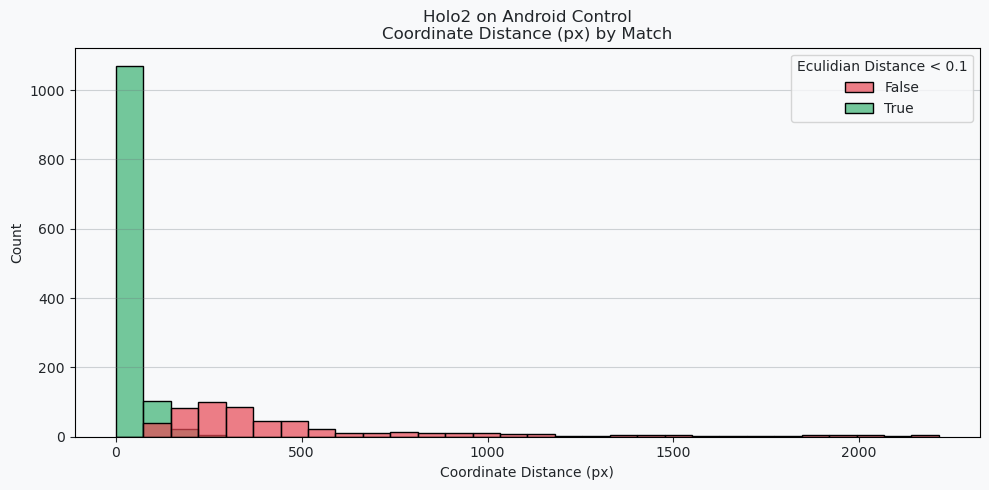

In [40]:
def plot_coord_dist_hist(stats_df, bins=30, figsize=(10, 5)):
    data = stats_df[["coord_dist_px", "coord_match"]].dropna(subset=["coord_dist_px"])

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    palette = {True: C2A_PALETTE["success"], False: C2A_PALETTE["warning"]}

    sns.histplot(
        data=data,
        x="coord_dist_px",
        hue="coord_match",
        bins=bins,
        palette=palette,
        alpha=0.7,
        ax=ax,
    )

    ax.set_xlabel("Coordinate Distance (px)", color=C2A_PALETTE["text"])
    ax.set_ylabel("Count", color=C2A_PALETTE["text"])
    ax.set_title(
        f"{MODEL_NAME} on Android Control\nCoordinate Distance (px) by Match",
        color=C2A_PALETTE["text"], fontsize=12,
    )
    ax.tick_params(colors=C2A_PALETTE["text"])
    ax.grid(axis="y", color=C2A_PALETTE["neutral"], alpha=0.3)

    legend = ax.get_legend()
    if legend:
        legend.get_frame().set_facecolor(C2A_PALETTE["bg"])
        for text in legend.get_texts():
            text.set_color(C2A_PALETTE["text"])
        legend.set_title("Eculidian Distance < 0.1")
        legend.get_title().set_color(C2A_PALETTE["text"])

    plt.tight_layout()
    plt.savefig("./results/histogram-eculdian-dist-px.png")
    plt.show()


plot_coord_dist_hist(stats_df)

In [93]:
modes = stats_df["failure_reason"].apply(lambda x: x.split("(")[0])
counts = modes.value_counts(normalize=True)
counts

failure_reason
ok                   0.631285
coord_too_far        0.232058
wrong_action_type    0.071336
wrong_direction      0.035668
text_mismatch        0.029652
Name: proportion, dtype: float64

/tmp/ipykernel_843877/3369165009.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{v*100:.0f}%" for v in vals], color=C2A_PALETTE["text"])


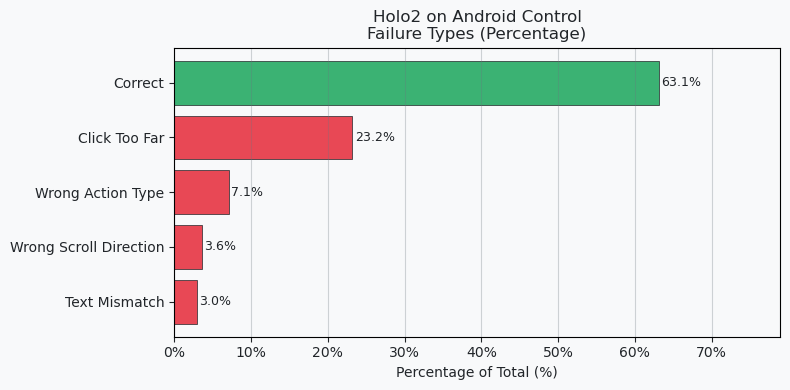

In [90]:
LABEL2NAME = {
    "ok":                "Correct",
    "coord_too_far":     "Click Too Far",
    "wrong_action_type": "Wrong Action Type",
    "wrong_direction":   "Wrong Scroll Direction",
    "text_mismatch":     "Text Mismatch",
}

def plot_failure_modes(stats_df, exclude_ok=False, figsize=(8, 4)):
    modes = stats_df["failure_reason"].apply(lambda x: x.split("(")[0])
    counts = modes.value_counts()
    total = len(stats_df)
    # REFINED [old]: counts = modes.value_counts() → [new]: counts = modes.value_counts(); total = len(stats_df)
    percentages = counts / total

    if exclude_ok:
        percentages = percentages.drop("ok", errors="ignore")

    percentages.index = [LABEL2NAME.get(k, k) for k in percentages.index]
    ok_label = LABEL2NAME["ok"]
    colors = [C2A_PALETTE["success"] if k == ok_label else C2A_PALETTE["warning"] for k in percentages.index[::-1]]

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    ax.barh(
        percentages.index[::-1],
        percentages.values[::-1],
        color=colors,
        linewidth=0.5,
        edgecolor=C2A_PALETTE["text"],
    )

    for i, val in enumerate(percentages.values[::-1]):
        ax.text(
            val + 0.003, i,
            f"{val:.1%}",
            va="center", color=C2A_PALETTE["text"], fontsize=9,
        )

    # REFINED [old]: ax.set_xlabel("Count", color=C2A_PALETTE["text"]) → [new]: ax.set_xlabel("Percentage of Total (%)", color=C2A_PALETTE["text"])
    ax.set_xlabel("Percentage of Total (%)", color=C2A_PALETTE["text"])
    ax.set_title(f"{MODEL_NAME} on Android Control\nFailure Types (Percentage)", color=C2A_PALETTE["text"], fontsize=12)
    ax.tick_params(colors=C2A_PALETTE["text"])
    # REFINED [old]: ax.set_xlim(0, counts.max() * 1.25) → [new]: ax.set_xlim(0, min(1.0, percentages.max() * 1.25))
    ax.set_xlim(0, min(1.0, percentages.max() * 1.25))
    ax.grid(axis="x", color=C2A_PALETTE["neutral"], alpha=0.3)

    vals = ax.get_xticks()
    ax.set_xticklabels([f"{v*100:.0f}%" for v in vals], color=C2A_PALETTE["text"])

    plt.tight_layout()
    plt.savefig("./results/failure_types_breakdown_pct.png")
    plt.show()


plot_failure_modes(stats_df)

/tmp/ipykernel_843877/115024805.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{v*100:.0f}%" for v in vals], color=C2A_PALETTE["text"])


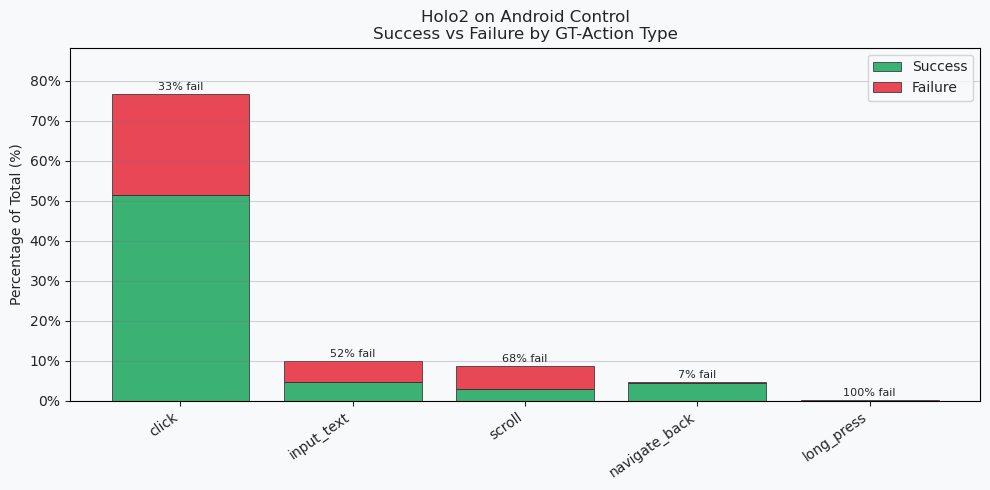

In [85]:
def plot_action_type_breakdown(stats_df, figsize=(10, 5)):
    summary = stats_df.groupby("gt_action_type").agg(
        total=("failure_reason", "count"),
        failed=("failure_reason", lambda x: (x != "ok").sum()),
    ).sort_values("total", ascending=False)
    summary["success"] = summary["total"] - summary["failed"]
    # REFINED [old]: summary["success"] = summary["total"] - summary["failed"] → [new]: summary["success"] = summary["total"] - summary["failed"]

    grand_total = summary["total"].sum()
    summary["success_pct"] = summary["success"] / grand_total
    summary["failed_pct"] = summary["failed"] / grand_total

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    x = range(len(summary))
    # Plot stacked bars with percentages instead of counts
    success_bars = ax.bar(x, summary["success_pct"], color=C2A_PALETTE["success"], label="Success", edgecolor=C2A_PALETTE["text"], linewidth=0.5)
    fail_bars = ax.bar(x, summary["failed_pct"], color=C2A_PALETTE["warning"], label="Failure", bottom=summary["success_pct"], edgecolor=C2A_PALETTE["text"], linewidth=0.5)

    for i, (_, row) in enumerate(summary.iterrows()):
        total_pct = row["total"] / grand_total
        ax.text(i, total_pct + 0.01, f'{(row["failed"]/row["total"]):.0%} fail',
                ha="center", color=C2A_PALETTE["text"], fontsize=8)

    ax.set_xticks(list(x))
    ax.set_xticklabels(summary.index, rotation=35, ha="right", color=C2A_PALETTE["text"])
    # REFINED [old]: ax.set_ylabel("Count", color=C2A_PALETTE["text"]) → [new]: ax.set_ylabel("Percentage of Total (%)", color=C2A_PALETTE["text"])
    ax.set_ylabel("Percentage of Total (%)", color=C2A_PALETTE["text"])
    ax.set_title(f"{MODEL_NAME} on Android Control\nSuccess vs Failure by GT-Action Type",
                 color=C2A_PALETTE["text"], fontsize=12)
    ax.tick_params(colors=C2A_PALETTE["text"])
    ax.grid(axis="y", color=C2A_PALETTE["neutral"], alpha=0.3)
    ax.legend(facecolor=C2A_PALETTE["bg"], labelcolor=C2A_PALETTE["text"])
    ax.set_ylim(0, min(1.0, summary[["success_pct", "failed_pct"]].sum(axis=1).max() * 1.15))

    vals = ax.get_yticks()
    # Set as percent on y axis
    ax.set_yticklabels([f"{v*100:.0f}%" for v in vals], color=C2A_PALETTE["text"])

    plt.tight_layout()
    plt.savefig("./results/action-type-breakdown.png")
    plt.show()


plot_action_type_breakdown(stats_df)

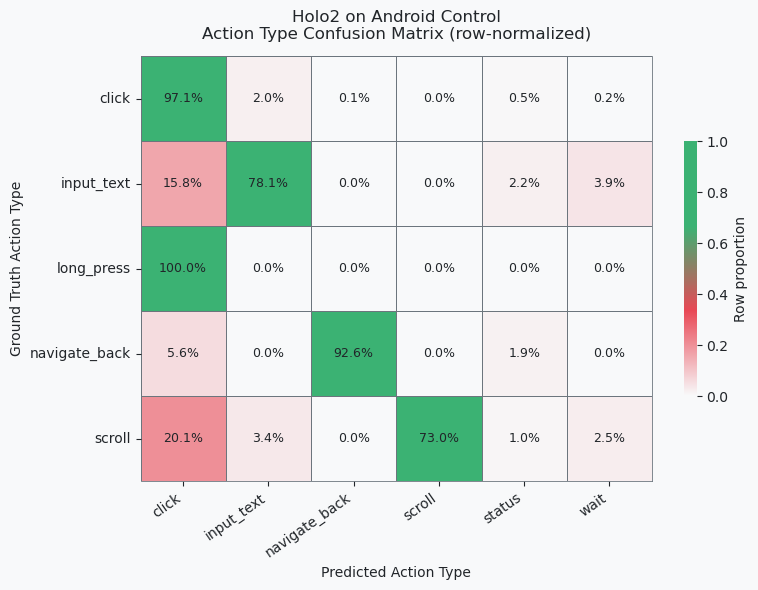

In [ ]:
    def plot_action_type_confusion(stats_df, figsize=(8, 6)):
        ct = pd.crosstab(stats_df["gt_action_type"], stats_df["pred_action_type"])

        # normalize by row (true label) to get recall-style rates
        ct_norm = ct.div(ct.sum(axis=1), axis=0)

        cmap = mcolors.LinearSegmentedColormap.from_list(
            "c2a", [C2A_PALETTE["bg"], C2A_PALETTE["warning"], C2A_PALETTE["success"], C2A_PALETTE["success"]]
        )

        fig, ax = plt.subplots(figsize=figsize)
        fig.patch.set_facecolor(C2A_PALETTE["bg"])
        ax.set_facecolor(C2A_PALETTE["bg"])

        # REFINED [old]: annot = ct_norm.applymap(lambda v: f"{v*100:.1f}%") → [new]: annot = ct_norm.map(lambda v: f"{v*100:.1f}%")
        annot = ct_norm.map(lambda v: f"{v*100:.1f}%")
        # REFINED [old]: sns.heatmap(..., annot=annot, ...) → [new]: Convert annot DataFrame to numpy array to avoid Seaborn formatting bug in recent versions.
        hm = sns.heatmap(
            ct_norm,
            annot=annot.values if hasattr(annot, "values") else annot,
            fmt="",
            cmap=cmap,
            vmin=0, vmax=1,
            linewidths=0.4,
            linecolor=C2A_PALETTE["neutral"],
            ax=ax,
            annot_kws={"color": C2A_PALETTE["text"], "size": 9},
            cbar_kws={"shrink": 0.6, "label": "Row proportion"},
        )

        # Add bottom and right borders to heatmap
        # Get axis limits
        x_left, x_right = ax.get_xlim()
        y_bottom, y_top = ax.get_ylim()
        # Draw right border
        ax.plot([x_right, x_right], [y_bottom, y_top], color=C2A_PALETTE["neutral"], linewidth=0.6, zorder=3, clip_on=False)
        # Draw bottom border
        ax.plot([x_left, x_right], [y_bottom, y_bottom], color=C2A_PALETTE["neutral"], linewidth=0.6, zorder=3, clip_on=False)

        ax.set_title(f"{MODEL_NAME} on Android Control\nAction Type Confusion Matrix (row-normalized)",
                    color=C2A_PALETTE["text"], fontsize=12, pad=12)
        ax.set_xlabel("Predicted Action Type", color=C2A_PALETTE["text"])
        ax.set_ylabel("Ground Truth Action Type", color=C2A_PALETTE["text"])
        plt.setp(ax.get_xticklabels(), color=C2A_PALETTE["text"], rotation=35, ha="right")
        plt.setp(ax.get_yticklabels(), color=C2A_PALETTE["text"], rotation=0)
        ax.tick_params(colors=C2A_PALETTE["text"])
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(colors=C2A_PALETTE["text"])
        cbar.ax.yaxis.label.set_color(C2A_PALETTE["text"])

        plt.tight_layout()
        plt.savefig("./results/action-type-confusion.png")
        plt.show()


    plot_action_type_confusion(stats_df)

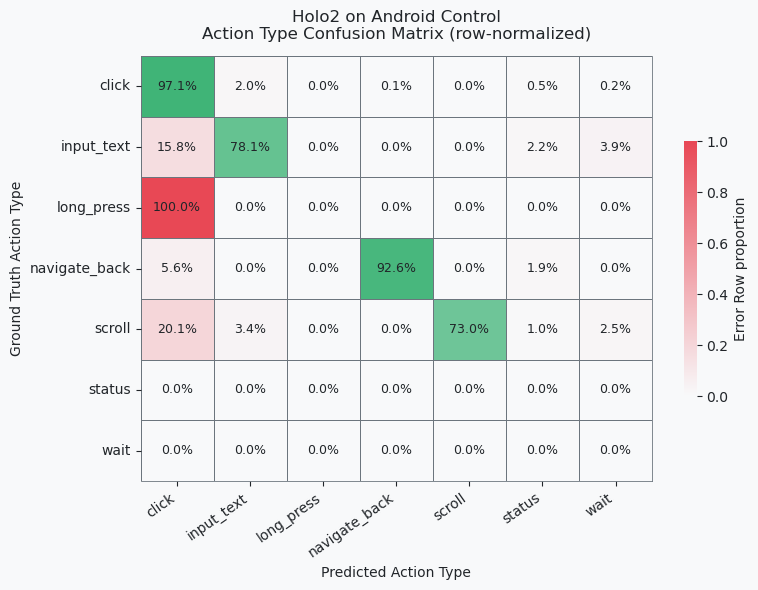

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

def plot_action_type_confusion(stats_df, figsize=(8, 6)):
    # 1. Align rows and columns to ensure a square matrix 
    # This guarantees the geometric diagonal is exactly GT == Pred
    labels = sorted(list(set(stats_df["gt_action_type"]) | set(stats_df["pred_action_type"])))
    ct = pd.crosstab(stats_df["gt_action_type"], stats_df["pred_action_type"])
    ct = ct.reindex(index=labels, columns=labels, fill_value=0)

    # Normalize by row (true label). fillna(0) protects against division by zero if a row is empty.
    ct_norm = ct.div(ct.sum(axis=1), axis=0).fillna(0)

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    # REFINED [old]: annot = ct_norm.map(lambda v: f"{v*100:.1f}%" if v > 0 else "") → [new]: annot = ct_norm.map(lambda v: f"{v*100:.1f}%")
    annot = ct_norm.map(lambda v: f"{v*100:.1f}%")
    annot_vals = annot.values if hasattr(annot, "values") else annot

    # 2. Create masks for the diagonal (Correct) and off-diagonal (Errors)
    is_diag = np.eye(len(labels), dtype=bool)

    # 3. Create two separate colormaps
    # Correct (Diagonal): Background -> Success (Green)
    cmap_correct = mcolors.LinearSegmentedColormap.from_list(
        "correct", [C2A_PALETTE["bg"], C2A_PALETTE["success"]]
    )
    # Errors (Off-diagonal): Background -> Warning (Orange/Yellow)
    # Note: If your C2A_PALETTE has a "danger" key, consider using it here instead of "warning"
    cmap_error = mcolors.LinearSegmentedColormap.from_list(
        "error", [C2A_PALETTE["bg"], C2A_PALETTE["warning"]]
    )

    # 4. Plot Errors (Mask out the diagonal)
    sns.heatmap(
        ct_norm,
        mask=is_diag,
        annot=annot_vals,
        fmt="",
        cmap=cmap_error,
        vmin=0, vmax=1,
        linewidths=0.4,
        linecolor=C2A_PALETTE["neutral"],
        ax=ax,
        annot_kws={"color": C2A_PALETTE["text"], "size": 9},
        cbar_kws={"shrink": 0.6, "label": "Error Row proportion"},
    )

    # 5. Plot Correct Predictions (Mask out the off-diagonal)
    sns.heatmap(
        ct_norm,
        mask=~is_diag,
        annot=annot_vals,
        fmt="",
        cmap=cmap_correct,
        vmin=0, vmax=1,
        linewidths=0.4,
        linecolor=C2A_PALETTE["neutral"],
        ax=ax,
        annot_kws={"color": C2A_PALETTE["text"], "size": 9},
        cbar=False, # Suppress second colorbar so they don't overlap
    )

    # Add bottom and right borders to heatmap
    x_left, x_right = ax.get_xlim()
    y_bottom, y_top = ax.get_ylim()
    ax.plot([x_right, x_right], [y_bottom, y_top], color=C2A_PALETTE["neutral"], linewidth=0.6, zorder=3, clip_on=False)
    ax.plot([x_left, x_right], [y_bottom, y_bottom], color=C2A_PALETTE["neutral"], linewidth=0.6, zorder=3, clip_on=False)

    ax.set_title(f"{MODEL_NAME} on Android Control\nAction Type Confusion Matrix (row-normalized)",
                 color=C2A_PALETTE["text"], fontsize=12, pad=12)
    ax.set_xlabel("Predicted Action Type", color=C2A_PALETTE["text"])
    ax.set_ylabel("Ground Truth Action Type", color=C2A_PALETTE["text"])
    plt.setp(ax.get_xticklabels(), color=C2A_PALETTE["text"], rotation=35, ha="right")
    plt.setp(ax.get_yticklabels(), color=C2A_PALETTE["text"], rotation=0)
    ax.tick_params(colors=C2A_PALETTE["text"])
    
    # Update colorbar ticks
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(colors=C2A_PALETTE["text"])
    cbar.ax.yaxis.label.set_color(C2A_PALETTE["text"])

    plt.tight_layout()
    plt.savefig("./results/action-type-confusion.png")
    plt.show()
    
plot_action_type_confusion(stats_df)

In [131]:
stats_df['gt_action_type'].value_counts()

gt_action_type
click            1785
input_text        228
scroll            204
navigate_back     108
long_press          2
Name: count, dtype: int64

In [ ]:
import numpy as np